In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X = np.array([
    95, 88, 76, 65, 54,
    43, 39, 28, 17, 82,
    91, 73, 66, 58, 47,
    36, 25, 14, 62, 79,
    84, 69, 55, 44, 33,
    22, 11, 97, 86, 75,
    64, 53, 42, 31, 20,
    10, 89, 78, 67, 56,
    45, 34, 23, 12, 99,
    92, 81, 70, 60, 50
])

y = np.array([1 if marks >= 40 else 0 for marks in X])


print("First 10 Marks:")
print(X[:10])

print("\nFirst 10 Labels:")
print(y[:10])


First 10 Marks:
[95 88 76 65 54 43 39 28 17 82]

First 10 Labels:
[1 1 1 1 1 1 0 0 0 1]


In [68]:
X = (X - X.min()) / (X.max() - X.min())
print(X)

[0.95505618 0.87640449 0.74157303 0.61797753 0.49438202 0.37078652
 0.3258427  0.20224719 0.07865169 0.80898876 0.91011236 0.70786517
 0.62921348 0.53932584 0.41573034 0.29213483 0.16853933 0.04494382
 0.58426966 0.7752809  0.83146067 0.66292135 0.50561798 0.38202247
 0.25842697 0.13483146 0.01123596 0.97752809 0.85393258 0.73033708
 0.60674157 0.48314607 0.35955056 0.23595506 0.11235955 0.
 0.88764045 0.76404494 0.64044944 0.51685393 0.39325843 0.26966292
 0.14606742 0.02247191 1.         0.92134831 0.79775281 0.6741573
 0.56179775 0.4494382 ]


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)
X

array([0.95505618, 0.87640449, 0.74157303, 0.61797753, 0.49438202,
       0.37078652, 0.3258427 , 0.20224719, 0.07865169, 0.80898876,
       0.91011236, 0.70786517, 0.62921348, 0.53932584, 0.41573034,
       0.29213483, 0.16853933, 0.04494382, 0.58426966, 0.7752809 ,
       0.83146067, 0.66292135, 0.50561798, 0.38202247, 0.25842697,
       0.13483146, 0.01123596, 0.97752809, 0.85393258, 0.73033708,
       0.60674157, 0.48314607, 0.35955056, 0.23595506, 0.11235955,
       0.        , 0.88764045, 0.76404494, 0.64044944, 0.51685393,
       0.39325843, 0.26966292, 0.14606742, 0.02247191, 1.        ,
       0.92134831, 0.79775281, 0.6741573 , 0.56179775, 0.4494382 ])

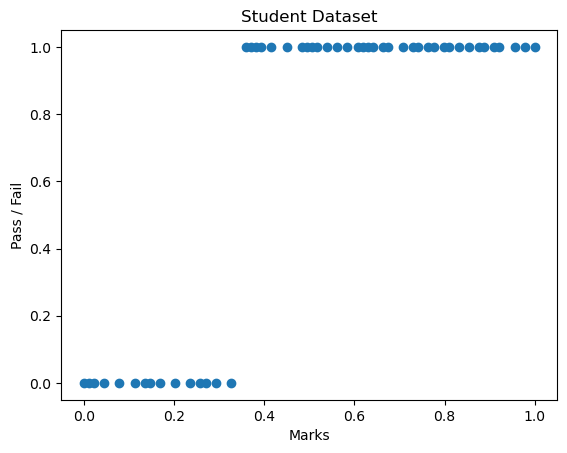

In [70]:
plt.scatter(X, y)
plt.xlabel("Marks")
plt.ylabel("Pass / Fail")
plt.title("Student Dataset")
plt.show()

In [71]:
X_train = np.array([X_train, np.ones(len(X_train))]).T
X_test = np.array([X_test, np.ones(len(X_test))]).T

parameters = np.zeros(X_train.shape[1])

In [ ]:
n = len(X_train)
epochs = 10000
learning_rate = 0.1
lossesLog = []
lossesMse = []
epsilon = 1e-9

for i in range(epochs):
    z = np.dot(X_train , parameters)
    y_pred = 1 / (1 + np.exp(-z))

    gradient = (1 / n) * np.dot(X_train.T, (y_pred - y_train))

    lossLog = -np.mean(y_train * np.log(y_pred + epsilon) +(1 - y_train) * np.log(1 - y_pred + epsilon))
  
    lossMSE =  np.mean((y_train - y_pred) ** 2)

    lossesLog.append(lossLog)
    lossesMse.append(lossMSE)
    
    parameters -= learning_rate * gradient
    # print("Log Loss : ",parameters)
    
# print(parameters)
print(lossMSE)

print(lossLog)

0.6931471785599455
0.6854285894087444
0.6781484273194536
0.6712789480369019
0.6647940144937992
0.6586690398694948
0.6528809256575681
0.6474079963547962
0.6422299321337291
0.6373277006337696
0.6326834888023363
0.6282806355382775
0.6241035657333439
0.620137726172801
0.6163695236414258
0.6127862654843182
0.609376102791178
0.6061279763060711
0.6030315651104103
0.6000772380831787
0.5972560081078435
0.5945594889684921
0.5919798548572893
0.5895098024002927
0.58714251509805
0.5848716300704208
0.5826912069910304
0.580595699095083
0.5785799261444448
0.5766390492355438
0.5747685473383762
0.5729641954584686
0.5712220443178122
0.5695384014553377
0.5679098136523194
0.5663330505930327
0.5648050896759749
0.5633231018958896
0.5618844387216834
0.5604866199000175
0.5591273221189005
0.5578043684699342
0.5565157186520165
0.5552594598632115
0.5540337983312127
0.5528370514363136
0.551667640384071
0.5505240833879287
0.5494049893249254
0.5483090518303069
0.5472350437993463
0.5461818122670041
0.5451482736382245

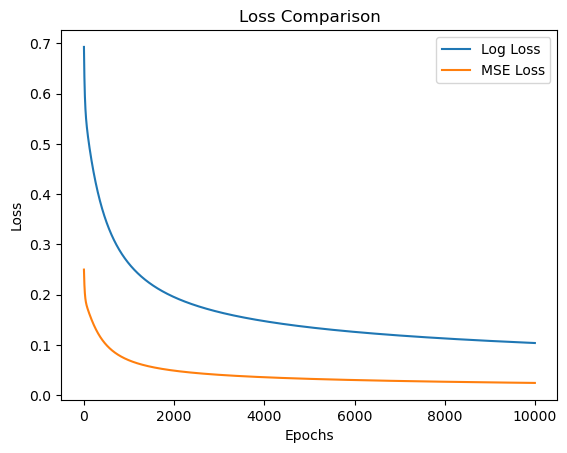

In [73]:
plt.plot(lossesLog, label='Log Loss')
plt.plot(lossesMse, label='MSE Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")

plt.legend()
plt.show()

0.32685373257445494


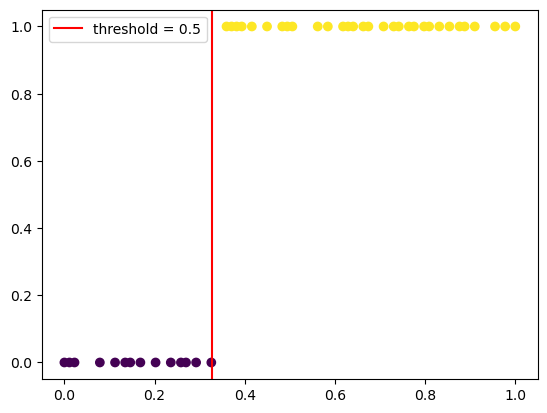

In [74]:
w = parameters[0]
b = parameters[1]

threshold = 0.5

# σ(z)=0.5
# z=log(0.3/1 - 0.3​)
z_thresh = np.log(threshold / (1 - threshold))

x_boundary = (z_thresh - b) / w
print(x_boundary)
plt.scatter(X_train[:,0] , y_train , c = y_train)

plt.axvline(x_boundary, color='red', label="threshold = 0.5")

plt.legend()
plt.show()

In [75]:
z = np.dot(X_test , parameters)
y_pred_test = 1 / (1 + np.exp(-z))
loss = -np.mean(y_test * np.log(y_pred_test) +(1 - y_test) * np.log(1 - y_pred_test))
print(loss)

0.023454406555939424


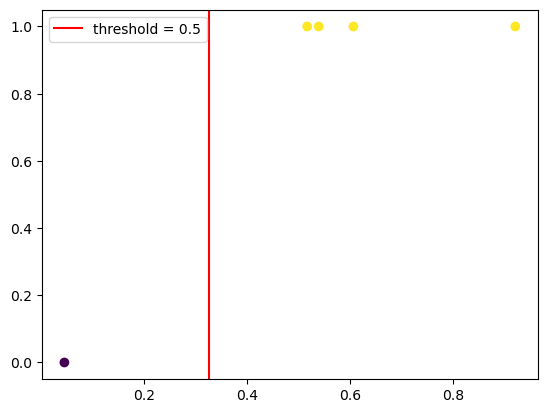

In [76]:
plt.scatter(X_test[:,0] , y_test , c = y_test)

plt.axvline(x_boundary , color='red', label="threshold = 0.5")

plt.legend()
plt.show()

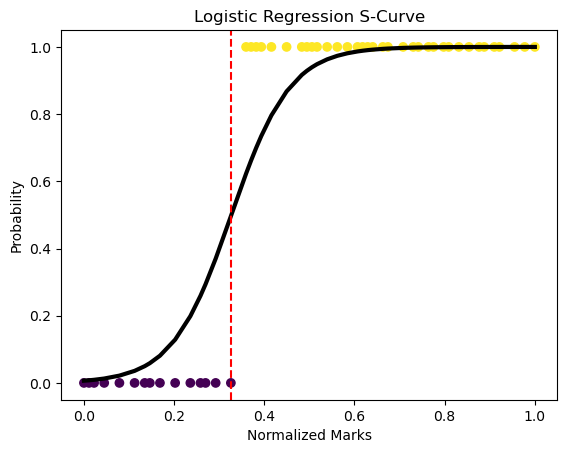

In [77]:
# Sort X values
sorted_indices = np.argsort(X)

X_sorted = X[sorted_indices]

# Apply model
z_curve = (X_sorted * w) + b

# Sigmoid
y_curve = 1 / (1 + np.exp(-z_curve))

# Plot actual data
plt.scatter(X, y, c=y)

# Plot smooth curve
plt.plot(X_sorted, y_curve, linewidth=3, color='black')

# Decision boundary
plt.axvline(x_boundary, color='red', linestyle='--')

plt.xlabel("Normalized Marks")
plt.ylabel("Probability")

plt.title("Logistic Regression S-Curve")

plt.show()